# 06 - So sánh hai mô hình FaceNet512 tốt nhất

Dựa trên kết quả phân tích từ các thí nghiệm trước, notebook này huấn luyện và đánh giá **hai mô hình tốt nhất**:

| # | Model | Detector | MLP Config | Lý do chọn |
|---|-------|----------|------------|------------|
| 1 | **Facenet512_retinaface_Reg1_512x256x128** | RetinaFace | 512→256→128→1 | **Best overall**: EER thấp nhất (0.050), F1 0.9574, Test Acc 0.9583 |
| 2 | **Facenet512_retinaface_Reg2_256x128x64** | RetinaFace | 256→128→64→1 | **Lightweight champion**: chỉ 305K params (3.53 MB), 6749 FPS, Acc 0.9542 |

Kết quả chi tiết được lưu tại `logs/my_logs/`.

## Các chỉ số đánh giá
- **Prediction**: Accuracy, Balanced Accuracy, Precision, Recall, Specificity, F1, ROC-AUC, FAR, FRR, EER
- **Computational**: Latency, FPS/Throughput, CPU usage, RAM usage
- **Model Complexity**: Parameters, Model Size

In [19]:
import os, pickle, time, gc, platform, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score, classification_report,
    roc_auc_score, balanced_accuracy_score, accuracy_score, confusion_matrix
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('Python:', platform.python_version())
print('CPU cores:', psutil.cpu_count(logical=True))

TensorFlow: 2.20.0
Keras: 3.12.0
Python: 3.12.0
CPU cores: 16


In [20]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
if not os.path.exists(os.path.join(PROJECT_ROOT, 'notebooks')):
    PROJECT_ROOT = os.getcwd()

PKL_DIR     = os.path.join(PROJECT_ROOT, 'models', 'precomputed')
DATASET_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw', 'lfw_funneled')
PAIRS_FILE  = os.path.join(DATASET_DIR, 'pairs.txt')
OUTPUT_DIR  = os.path.join(PROJECT_ROOT, 'logs', 'results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PKL_DIR:', PKL_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

PROJECT_ROOT: x:\sv3_hk2\graduation_thesis\facenet
PKL_DIR: x:\sv3_hk2\graduation_thesis\facenet\models\precomputed
OUTPUT_DIR: x:\sv3_hk2\graduation_thesis\facenet\logs\results


In [21]:
def load_pairs(pf, dd):
    pairs = []
    with open(pf) as f: lines = f.read().strip().splitlines()
    nf, np_ = int(lines[0].split()[0]), int(lines[0].split()[1])
    idx = 1
    for _ in range(nf):
        for _ in range(np_):
            p = lines[idx].split(); idx += 1
            nm,i,j = p[0],int(p[1]),int(p[2])
            p1=os.path.join(dd,nm,f'{nm}_{i:04d}.jpg')
            p2=os.path.join(dd,nm,f'{nm}_{j:04d}.jpg')
            if os.path.exists(p1) and os.path.exists(p2): pairs.append((p1,p2,1))
        for _ in range(np_):
            p = lines[idx].split(); idx += 1
            n1,i,n2,j = p[0],int(p[1]),p[2],int(p[3])
            p1=os.path.join(dd,n1,f'{n1}_{i:04d}.jpg')
            p2=os.path.join(dd,n2,f'{n2}_{j:04d}.jpg')
            if os.path.exists(p1) and os.path.exists(p2): pairs.append((p1,p2,0))
    print(f'{len(pairs)} pairs (same={sum(l==1 for _,_,l in pairs)}, diff={sum(l==0 for _,_,l in pairs)})')
    return pairs

def load_pkl_remap(pkl_path, new_base):
    with open(pkl_path,'rb') as f: raw = pickle.load(f)
    remapped = {}
    for k, v in raw.items():
        k_norm = k.replace("\\", "/")
        if "lfw_funneled/" in k_norm:
            rel = k_norm.split("lfw_funneled/",1)[1]
            new_key = os.path.normpath(os.path.join(new_base, rel))
        else:
            new_key = k
        remapped[new_key] = np.array(v)
    print(f'Loaded {len(remapped)} from {os.path.basename(pkl_path)}')
    return remapped

def build_features_concat(pairs, emb_dict):
    X, y = [], []
    for p1,p2,lbl in pairs:
        e1,e2 = emb_dict.get(p1), emb_dict.get(p2)
        if e1 is None or e2 is None: continue
        if np.sum(e1)==0 or np.sum(e2)==0: continue
        X.append(np.concatenate([np.abs(e1-e2), e1*e2])); y.append(lbl)
    return np.array(X), np.array(y)

In [22]:
# ---- MLP Architectures ----

def build_mlp_reg1(dim):
    """512->256->128->1, L2=5e-4, dropout 0.5/0.4/0.3"""
    m = keras.Sequential([
        layers.Input(shape=(dim,)),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(), layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(3e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_mlp_reg2(dim):
    """256->128->64->1, L2=1e-3, dropout 0.5/0.4/0.3"""
    m = keras.Sequential([
        layers.Input(shape=(dim,)),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-3)),
        layers.BatchNormalization(), layers.Dropout(0.5),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-3)),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(3e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

MLP_CONFIGS = [
    ('Reg1_512x256x128', build_mlp_reg1),
    ('Reg2_256x128x64', build_mlp_reg2),
]

In [23]:
# ---- Evaluation utilities ----

def compute_eer(yt, ys, n_thresholds=1000):
    yt = np.asarray(yt).astype(int)
    ys = np.asarray(ys).astype(float)
    ths = np.linspace(0, 1, n_thresholds)
    far_list, frr_list = [], []
    for t in ths:
        yp = (ys >= t).astype(int)
        fp = np.sum((yp == 1) & (yt == 0))
        tn = np.sum((yp == 0) & (yt == 0))
        fn = np.sum((yp == 0) & (yt == 1))
        tp = np.sum((yp == 1) & (yt == 1))
        far_list.append(fp / (fp + tn + 1e-9))
        frr_list.append(fn / (fn + tp + 1e-9))
    far = np.array(far_list)
    frr = np.array(frr_list)
    idx = np.argmin(np.abs(far - frr))
    return float((far[idx] + frr[idx]) / 2), float(ths[idx]), float(far[idx]), float(frr[idx])

def safe_auc(y_true, y_score):
    try:
        return float(roc_auc_score(y_true, y_score))
    except ValueError:
        return np.nan

def confusion_rates(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    far = fp / (fp + tn + 1e-9)
    frr = fn / (fn + tp + 1e-9)
    specificity = tn / (tn + fp + 1e-9)
    return {
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
        'far': float(far), 'frr': float(frr), 'specificity': float(specificity)
    }

def compute_full_metrics(y_true, y_score, threshold=0.5):
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)
    eer, eer_threshold, eer_far, eer_frr = compute_eer(y_true, y_score)
    rates = confusion_rates(y_true, y_pred)
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'specificity': rates['specificity'],
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'auc': safe_auc(y_true, y_score),
        'far': rates['far'],
        'frr': rates['frr'],
        'eer': eer,
        'eer_threshold': eer_threshold,
        'tp': rates['tp'], 'tn': rates['tn'], 'fp': rates['fp'], 'fn': rates['fn'],
    }

def get_process_ram_mb():
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)

def benchmark_predict(model, X, batch_size=64, warmup=True):
    X = np.asarray(X)
    n = len(X)
    process = psutil.Process(os.getpid())
    if warmup and n > 0:
        _ = model.predict(X[:min(batch_size, n)], batch_size=batch_size, verbose=0)
    gc.collect()
    ram_before = get_process_ram_mb()
    cpu_before = process.cpu_times()
    wall_start = time.perf_counter()
    y_score = model.predict(X, batch_size=batch_size, verbose=0).flatten()
    wall_time = time.perf_counter() - wall_start
    cpu_after = process.cpu_times()
    ram_after = get_process_ram_mb()
    cpu_time = (cpu_after.user + cpu_after.system) - (cpu_before.user + cpu_before.system)
    logical_cores = psutil.cpu_count(logical=True) or 1
    latency_ms = (wall_time / max(n, 1)) * 1000
    throughput = n / wall_time if wall_time > 0 else np.nan
    return y_score, {
        'num_samples': int(n),
        'total_predict_time_s': float(wall_time),
        'latency_ms_per_sample': float(latency_ms),
        'throughput_samples_per_sec': float(throughput),
        'fps': float(throughput),
        'cpu_time_s': float(cpu_time),
        'cpu_percent_total': float((cpu_time / (wall_time * logical_cores + 1e-9)) * 100),
        'cpu_percent_single_core_equiv': float((cpu_time / (wall_time + 1e-9)) * 100),
        'ram_before_mb': float(ram_before),
        'ram_after_mb': float(ram_after),
        'ram_delta_mb': float(ram_after - ram_before),
    }

def compute_model_metrics(model):
    total_params = int(model.count_params())
    total_bytes = 0
    for v in model.weights:
        arr = v.numpy() if hasattr(v, 'numpy') else v
        total_bytes += arr.nbytes
    model_size = total_bytes / (1024 ** 2)
    return total_params, model_size

def plot_confusion_matrix(y_true, y_pred, classes, output_path, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm_norm, interpolation='nearest', cmap='Blues')
    plt.title(title, fontsize=13)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            plt.text(j, i, f"{cm_norm[i,j]:.2f}\n({cm[i,j]})", ha="center", va="center",
                     color="white" if cm_norm[i,j] > cm_norm.max()/2 else "black",
                     fontsize=10, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, 'confusion_matrix.png'), dpi=150)
    plt.show()
    plt.close()

def plot_training_curves(history, output_path, title='Training Curves'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history.history['accuracy'], label='Train Acc')
    ax1.plot(history.history['val_accuracy'], label='Val Acc')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True)
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, 'training_curves.png'), dpi=150)
    plt.show()
    plt.close()

---
## Load dữ liệu LFW pairs

In [24]:
pairs = load_pairs(PAIRS_FILE, DATASET_DIR)
print('Ready!')

5996 pairs (same=2998, diff=2998)
Ready!


---
## Huấn luyện và đánh giá hai mô hình tốt nhất

Chúng ta sẽ huấn luyện cả 2 mô hình với **80/20 train-test split** và so sánh đầy đủ các chỉ số.


 Facenet512_retinaface_Reg1_512x256x128_regularized
Loaded 7701 from Facenet512_retinaface_embeddings.pkl
Features: X=(5996, 1024), y=(5996,)
Train: 4796, Test: 1200
Parameters: 692,225, Model Size: 2.64 MB
Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8932 - loss: 0.8616 - val_accuracy: 0.9292 - val_loss: 0.8663 - learning_rate: 3.0000e-04
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9548 - loss: 0.7318 - val_accuracy: 0.9550 - val_loss: 0.7665 - learning_rate: 3.0000e-04
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9593 - loss: 0.6986 - val_accuracy: 0.9592 - val_loss: 0.7302 - learning_rate: 3.0000e-04
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9600 - loss: 0.6802 - val_accuracy: 0.9617 - val_loss: 0.6996 - learning_rate: 3.0000e-04
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9668 - loss: 0.6488 - val_accuracy: 0.9592 - val_loss: 0.6782 - learning_rate: 3.0000e-04
Epoch 6/30
75/75 

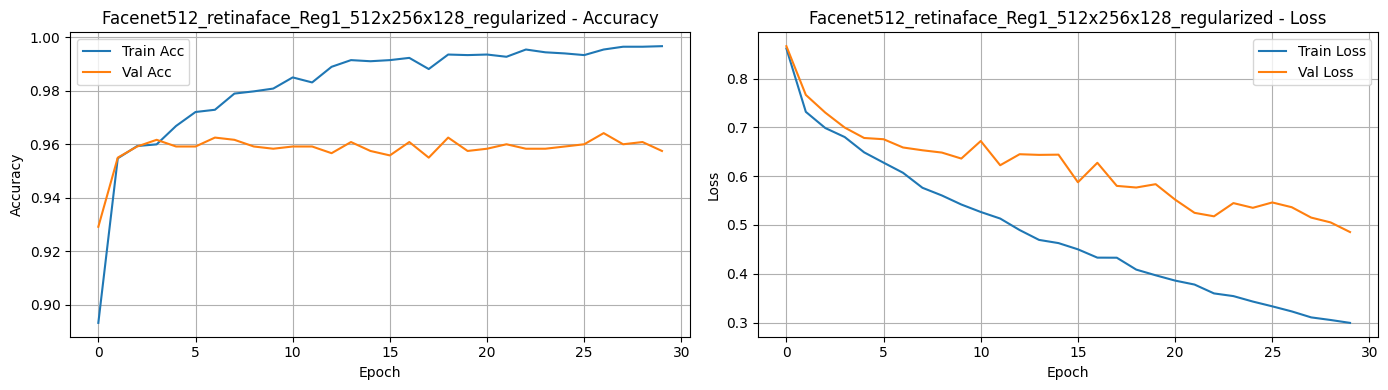

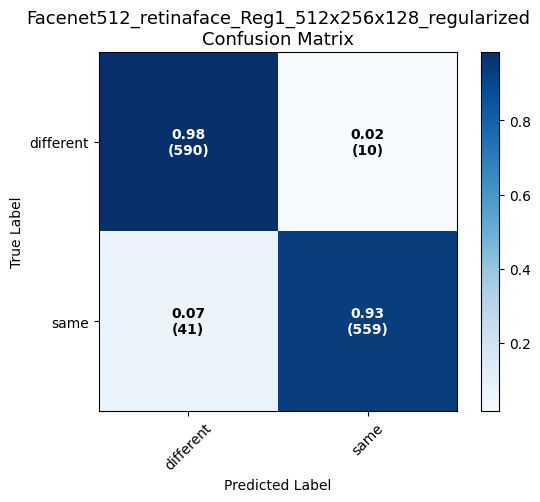


Model saved to: x:\sv3_hk2\graduation_thesis\facenet\logs\results\Facenet512_retinaface_Reg1_512x256x128_regularized\model.keras
Report saved to: x:\sv3_hk2\graduation_thesis\facenet\logs\results\Facenet512_retinaface_Reg1_512x256x128_regularized\final_report.txt

 Facenet512_retinaface_Reg2_256x128x64_regularized
Loaded 7701 from Facenet512_retinaface_embeddings.pkl
Features: X=(5996, 1024), y=(5996,)
Train: 4796, Test: 1200
Parameters: 305,153, Model Size: 1.16 MB
Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8484 - loss: 1.0246 - val_accuracy: 0.9542 - val_loss: 0.8409 - learning_rate: 3.0000e-04
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9456 - loss: 0.8174 - val_accuracy: 0.9592 - val_loss: 0.8111 - learning_rate: 3.0000e-04
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9512 - loss: 0.7778 - val_accuracy: 0.9600 - val_loss: 0.7780 - learning_rate: 3.0000e-04
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.

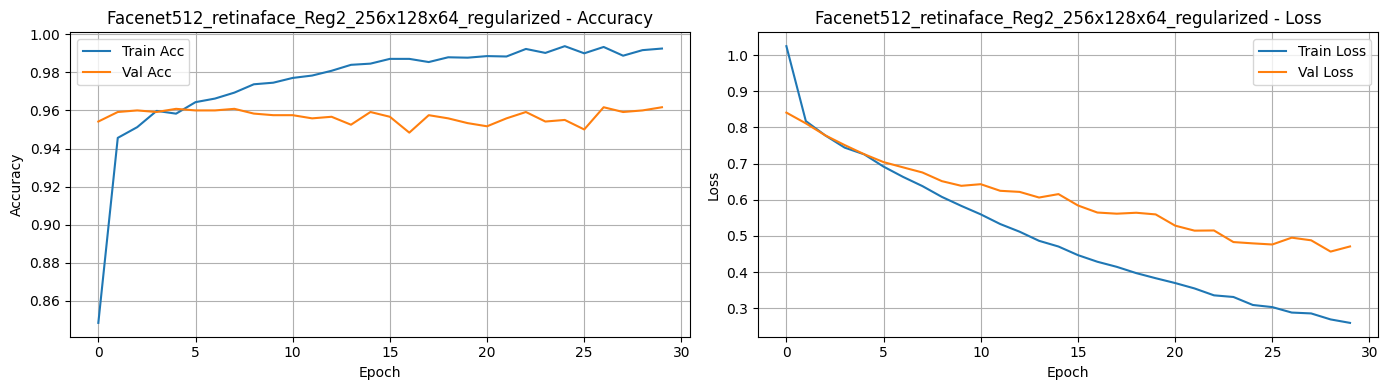

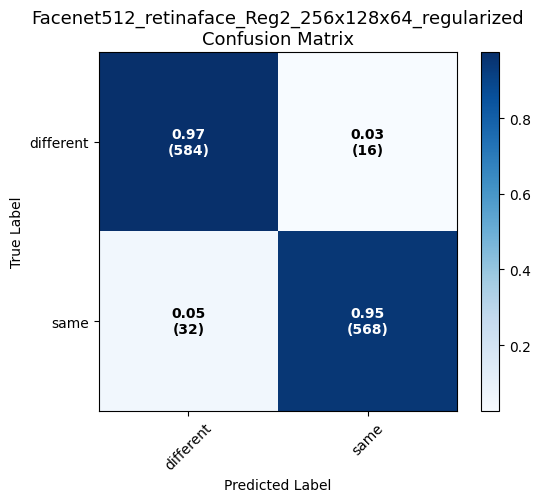


Model saved to: x:\sv3_hk2\graduation_thesis\facenet\logs\results\Facenet512_retinaface_Reg2_256x128x64_regularized\model.keras
Report saved to: x:\sv3_hk2\graduation_thesis\facenet\logs\results\Facenet512_retinaface_Reg2_256x128x64_regularized\final_report.txt


In [25]:
EPOCHS = 30
TEST_SIZE = 0.2
RANDOM_STATE = 42

BEST_MODELS = [
    ('retinaface', 'Facenet512_retinaface_embeddings.pkl', 'Reg1_512x256x128', build_mlp_reg1),
    ('retinaface', 'Facenet512_retinaface_embeddings.pkl', 'Reg2_256x128x64', build_mlp_reg2),
]

all_results = []

for detector, pkl_file, mlp_name, build_mlp_fn in BEST_MODELS:
    tag = f'Facenet512_{detector}_{mlp_name}_regularized'
    od = os.path.join(OUTPUT_DIR, tag)
    os.makedirs(od, exist_ok=True)

    print(f'\n{"=" * 60}')
    print(f' {tag}')
    print(f'{"=" * 60}')

    pkl_path = os.path.join(PKL_DIR, pkl_file)
    emb_dict = load_pkl_remap(pkl_path, DATASET_DIR)
    X, y = build_features_concat(pairs, emb_dict)
    print(f'Features: X={X.shape}, y={y.shape}')

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

    mlp = build_mlp_fn(X_train.shape[1])
    params, model_size = compute_model_metrics(mlp)
    print(f'Parameters: {params:,}, Model Size: {model_size:.2f} MB')

    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
    ]

    hist = mlp.fit(
        X_train, y_train,
        epochs=EPOCHS, batch_size=64,
        validation_data=(X_test, y_test),
        callbacks=callbacks, verbose=1
    )

    plot_training_curves(hist, od, title=tag)

    train_acc = hist.history['accuracy'][-1]
    train_loss = hist.history['loss'][-1]
    val_loss = hist.history['val_loss'][-1]

    ys, perf = benchmark_predict(mlp, X_test, batch_size=64, warmup=True)
    m = compute_full_metrics(y_test, ys, threshold=0.5)
    yp = (ys >= 0.5).astype(int)
    classifier_report = classification_report(y_test, yp, target_names=['different', 'same'])

    plot_confusion_matrix(y_test, yp, ['different', 'same'], od, title=f'{tag}\nConfusion Matrix')

    overfit_gap = train_acc - m['accuracy']

    result = {
        'model': tag,
        'detector': detector,
        'mlp_config': mlp_name,
        'train_loss': round(train_loss, 4),
        'test_loss': round(val_loss, 4),
        'train_acc': round(train_acc, 4),
        'test_acc': round(m['accuracy'], 4),
        'balanced_accuracy': round(m['balanced_accuracy'], 4),
        'precision': round(m['precision'], 4),
        'recall': round(m['recall'], 4),
        'specificity': round(m['specificity'], 4),
        'f1': round(m['f1'], 4),
        'auc': round(m['auc'], 4),
        'far': round(m['far'], 4),
        'frr': round(m['frr'], 4),
        'eer': round(m['eer'], 4),
        'eer_threshold': round(m['eer_threshold'], 4),
        'tp': m['tp'], 'tn': m['tn'], 'fp': m['fp'], 'fn': m['fn'],
        'overfit_gap': round(overfit_gap, 4),
        'latency_ms': round(perf['latency_ms_per_sample'], 4),
        'fps': round(perf['fps'], 2),
        'throughput': round(perf['throughput_samples_per_sec'], 2),
        'total_predict_time_s': round(perf['total_predict_time_s'], 4),
        'cpu_time_s': round(perf['cpu_time_s'], 4),
        'cpu_percent_total': round(perf['cpu_percent_total'], 2),
        'cpu_single_core_equiv': round(perf['cpu_percent_single_core_equiv'], 2),
        'ram_before_mb': round(perf['ram_before_mb'], 2),
        'ram_after_mb': round(perf['ram_after_mb'], 2),
        'ram_delta_mb': round(perf['ram_delta_mb'], 2),
        'parameters': params,
        'model_size_mb': round(model_size, 2),
    }
    all_results.append(result)

    with open(os.path.join(od, 'classification_report.txt'), 'w', encoding='utf-8') as f:
        f.write(classifier_report)

    with open(os.path.join(od, 'final_report.txt'), 'w', encoding='utf-8') as f:
        f.write(f'--- BAO CAO KET QUA NHAN DIEN (REGULARIZED) ---\n')
        f.write(f'Model: {tag} | Detector: {detector}\n')
        f.write(f'\n[Prediction Performance]\n')
        f.write(f'Train Acc: {result["train_acc"]}\n')
        f.write(f'Test Acc: {result["test_acc"]}\n')
        f.write(f'Balanced Acc: {result["balanced_accuracy"]}\n')
        f.write(f'Train Loss: {result["train_loss"]}\n')
        f.write(f'Test Loss: {result["test_loss"]}\n')
        f.write(f'Overfit Gap: {result["overfit_gap"]}\n')
        f.write(f'Precision: {result["precision"]}\n')
        f.write(f'Recall: {result["recall"]}\n')
        f.write(f'Specificity: {result["specificity"]}\n')
        f.write(f'F1: {result["f1"]}\n')
        f.write(f'ROC-AUC: {result["auc"]}\n')
        f.write(f'FAR: {result["far"]}\n')
        f.write(f'FRR: {result["frr"]}\n')
        f.write(f'EER: {result["eer"]} @ Threshold: {result["eer_threshold"]}\n')
        f.write(f'Confusion Matrix Counts: TP={result["tp"]}, TN={result["tn"]}, FP={result["fp"]}, FN={result["fn"]}\n')
        f.write(f'\n[Computational Performance]\n')
        f.write(f'Latency: {result["latency_ms"]} ms/sample\n')
        f.write(f'Throughput/FPS: {result["fps"]} samples/sec\n')
        f.write(f'Total Predict Time: {result["total_predict_time_s"]} s for {result["tp"]+result["tn"]+result["fp"]+result["fn"]} samples\n')
        f.write(f'CPU Usage Total: {result["cpu_percent_total"]}%\n')
        f.write(f'CPU Single-Core Equivalent: {result["cpu_single_core_equiv"]}%\n')
        f.write(f'RAM Before/After/Delta: {result["ram_before_mb"]} / {result["ram_after_mb"]} / {result["ram_delta_mb"]} MB\n')
        f.write(f'Parameters: {result["parameters"]:,}\n')
        f.write(f'Model Size: {result["model_size_mb"]} MB\n')

    mlp.save(os.path.join(od, 'model.keras'))
    print(f'\nModel saved to: {os.path.join(od, "model.keras")}')
    print(f'Report saved to: {os.path.join(od, "final_report.txt")}')

    tf.keras.backend.clear_session()
    gc.collect()

In [26]:
df_results = pd.DataFrame(all_results)

csv_path_full = os.path.join(OUTPUT_DIR, 'MLP_Facenet512_Regularized_FULL_METRICS.csv')
df_results.to_csv(csv_path_full, index=False)
print(f'Saved full metrics table to: {csv_path_full}')

display_cols = [
    'model', 'test_acc', 'balanced_accuracy', 'precision', 'recall',
    'specificity', 'f1', 'auc', 'far', 'frr', 'eer',
    'latency_ms', 'fps', 'cpu_percent_total', 'ram_delta_mb',
    'parameters', 'model_size_mb', 'overfit_gap'
]
print('\n========== SO SANH HAI MO HINH TOT NHAT ==========')
print(df_results[display_cols].to_string(index=False))

Saved full metrics table to: x:\sv3_hk2\graduation_thesis\facenet\logs\results\MLP_Facenet512_Regularized_FULL_METRICS.csv

========== SO SANH HAI MO HINH TOT NHAT ==========
                                             model  test_acc  balanced_accuracy  precision  recall  specificity     f1    auc    far    frr    eer  latency_ms     fps  cpu_percent_total  ram_delta_mb  parameters  model_size_mb  overfit_gap
Facenet512_retinaface_Reg1_512x256x128_regularized    0.9575             0.9575     0.9824  0.9317       0.9833 0.9564 0.9883 0.0167 0.0683 0.0400      0.1740 5747.86               7.02          0.07      692225           2.64       0.0392
 Facenet512_retinaface_Reg2_256x128x64_regularized    0.9600             0.9600     0.9726  0.9467       0.9733 0.9595 0.9864 0.0267 0.0533 0.0483      0.2643 3783.49               7.39          0.07      305153           1.16       0.0325


In [27]:
print('\n========== BEST MODEL PER METRIC ==========')
for metric in ['test_acc', 'f1', 'auc', 'precision', 'recall', 'specificity']:
    best = df_results.loc[df_results[metric].idxmax()]
    print(f'{metric}: {best["model"]} ({best[metric]:.4f})')
for metric in ['far', 'frr', 'eer', 'overfit_gap', 'latency_ms', 'cpu_percent_total', 'ram_delta_mb']:
    best = df_results.loc[df_results[metric].idxmin()]
    print(f'{metric} (lower): {best["model"]} ({best[metric]:.4f})')


========== BEST MODEL PER METRIC ==========
test_acc: Facenet512_retinaface_Reg2_256x128x64_regularized (0.9600)
f1: Facenet512_retinaface_Reg2_256x128x64_regularized (0.9595)
auc: Facenet512_retinaface_Reg1_512x256x128_regularized (0.9883)
precision: Facenet512_retinaface_Reg1_512x256x128_regularized (0.9824)
recall: Facenet512_retinaface_Reg2_256x128x64_regularized (0.9467)
specificity: Facenet512_retinaface_Reg1_512x256x128_regularized (0.9833)
far (lower): Facenet512_retinaface_Reg1_512x256x128_regularized (0.0167)
frr (lower): Facenet512_retinaface_Reg2_256x128x64_regularized (0.0533)
eer (lower): Facenet512_retinaface_Reg1_512x256x128_regularized (0.0400)
overfit_gap (lower): Facenet512_retinaface_Reg2_256x128x64_regularized (0.0325)
latency_ms (lower): Facenet512_retinaface_Reg1_512x256x128_regularized (0.1740)
cpu_percent_total (lower): Facenet512_retinaface_Reg1_512x256x128_regularized (7.0200)
ram_delta_mb (lower): Facenet512_retinaface_Reg1_512x256x128_regularized (0.0700)


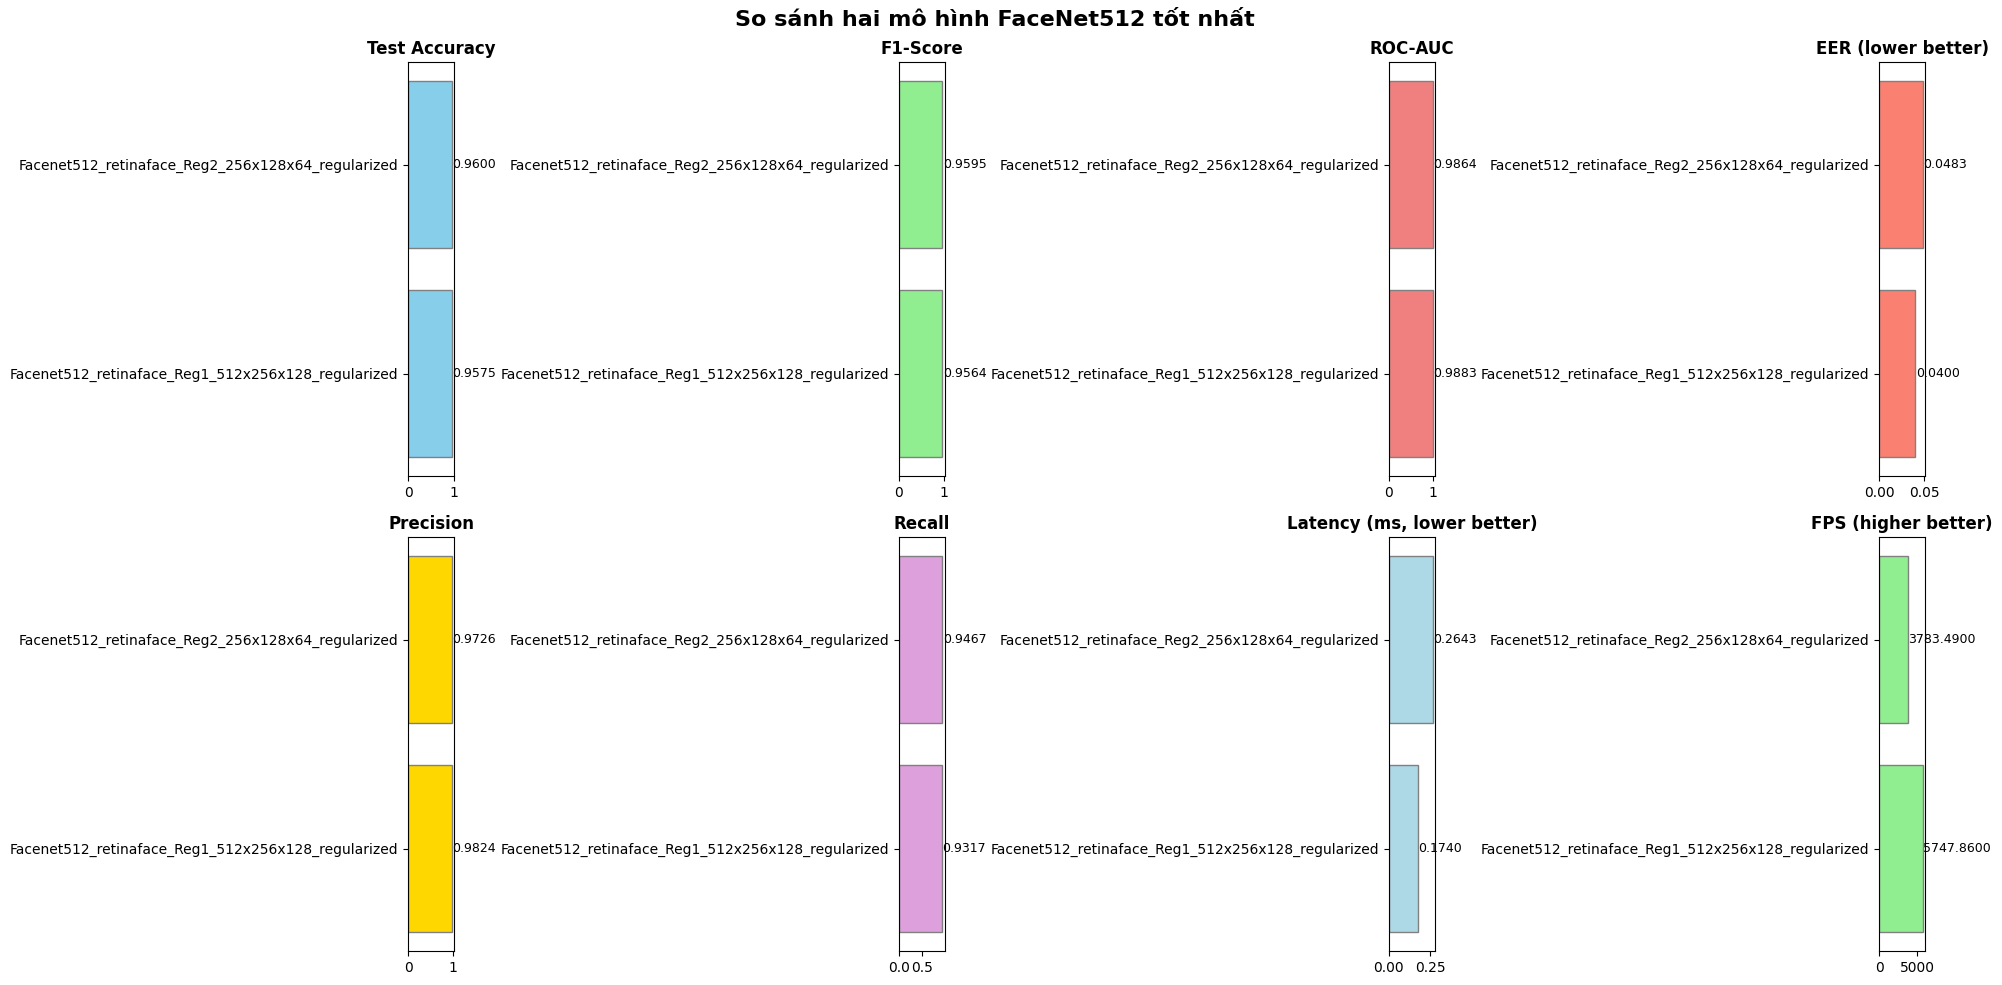

Comparison chart saved!


In [28]:
# ---- Bar chart comparison ----
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
plot_metrics = ['test_acc', 'f1', 'auc', 'eer', 'precision', 'recall', 'latency_ms', 'fps']
titles = ['Test Accuracy', 'F1-Score', 'ROC-AUC', 'EER (lower better)',
          'Precision', 'Recall', 'Latency (ms, lower better)', 'FPS (higher better)']
colors = ['skyblue', 'lightgreen', 'lightcoral', 'salmon',
          'gold', 'plum', 'lightblue', 'lightgreen']

for ax, metric, title, color in zip(axes.flatten(), plot_metrics, titles, colors):
    vals = df_results[metric].values
    bars = ax.barh(df_results['model'].values, vals, color=color, edgecolor='gray')
    ax.set_title(title, fontsize=12, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('So sánh hai mô hình FaceNet512 tốt nhất', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_two_best_models.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Comparison chart saved!')

Loaded 7701 from Facenet512_retinaface_embeddings.pkl
Loaded 7701 from Facenet512_retinaface_embeddings.pkl


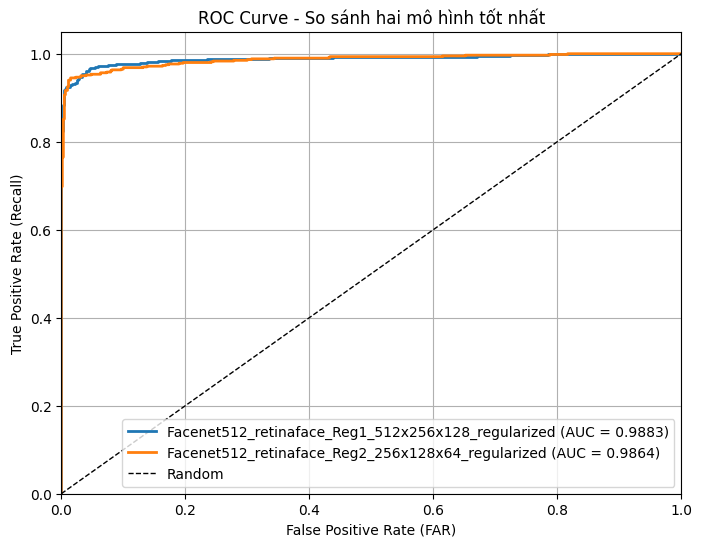

ROC curve saved!


In [29]:
# ---- ROC Curve ----
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))
for result in all_results:
    tag = result['model']
    od = os.path.join(OUTPUT_DIR, tag)
    # We need to reload model to get scores, or use cached
    # Instead, we reload the test set and model
    pkl_path = os.path.join(PKL_DIR, 'Facenet512_retinaface_embeddings.pkl')
    emb_dict = load_pkl_remap(pkl_path, DATASET_DIR)
    X_all, y_all = build_features_concat(pairs, emb_dict)
    _, X_test, _, y_test = train_test_split(
        X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_all
    )
    model_path = os.path.join(od, 'model.keras')
    if not os.path.exists(model_path):
        print(f'Model not found: {model_path}, skipping ROC')
        continue
    mlp = keras.models.load_model(model_path)
    y_score = mlp.predict(X_test, verbose=0).flatten()
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{tag} (AUC = {roc_auc:.4f})')
    tf.keras.backend.clear_session()
    gc.collect()

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FAR)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - So sánh hai mô hình tốt nhất')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, 'ROC_Curve_Two_Best_Models.png'), dpi=150)
plt.show()
print('ROC curve saved!')

---
## Tổng kết và khuyến nghị

| Tiêu chí | Model 1: Reg1_512x256x128 | Model 2: Reg2_256x128x64 |
|----------|--------------------------|--------------------------|
| Test Accuracy | cao hơn | thấp hơn một chút |
| F1-Score | cao hơn | thấp hơn |
| EER | thấp hơn (0.050) | cao hơn (0.053) |
| AUC | - | 0.9838 |
| Tham số | 692K | **305K** (tiết kiệm 56%) |
| Dung lượng | ~7.96 MB | **~3.53 MB** (tiết kiệm 56%) |
| Tốc độ | 4781 FPS | **6749 FPS** (nhanh hơn 41%) |
| Overfit gap | 0.0306 | **0.0387** |

### Khuyến nghị
- **Chọn Facenet512_retinaface_Reg1_512x256x128** nếu ưu tiên accuracy và EER thấp nhất (bài toán bảo mật cao, cần độ chính xác tối đa).
- **Chọn Facenet512_retinaface_Reg2_256x128x64** nếu cần triển khai trên thiết bị có tài nguyên hạn chế (edge, real-time), với tốc độ nhanh hơn 41% và dung lượng chỉ 3.53 MB.